In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
audi = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\audi.csv")
bmw = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\bmw.csv")
cclass = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\cclass.csv")
focus = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\focus.csv")
ford = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\ford.csv")
hyundai = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\hyundi.csv")
merc = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\merc.csv")
skoda = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\skoda.csv")
toyota = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\toyota.csv")
unclean_cclass = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\unclean cclass.csv")
unclean_focus = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\unclean focus.csv")
vauxhall = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\vauxhall.csv")
vw = pd.read_csv(r"C:\Users\hamza\Downloads\UK Used Car Data set\vw.csv")

In [3]:
#Standardize inconsistent column names BEFORE combining ---
# The hyundai file uses 'tax(£)' instead of 'tax' — if we don't fix this,
# concat will create two separate columns full of NaNs instead of one clean 'tax' column.

hyundai = hyundai.rename(columns={'tax(£)': 'tax'})

#Tag each dataframe with its manufacturer BEFORE combining ---
# Once we concat, individual rows lose any sense of "which file did this come from" —
# so we stamp that identity in now, while each dataframe is still separate.

audi['Make'] = 'Audi'
bmw['Make'] = 'BMW'
ford['Make'] = 'Ford'
hyundai['Make'] = 'Hyundai'
merc['Make'] = 'Mercedes'
skoda['Make'] = 'Skoda'
toyota['Make'] = 'Toyota'
vauxhall['Make'] = 'Vauxhall'
vw['Make'] = 'Volkswagen'

In [4]:
df = pd.concat(
    [audi, bmw, ford, hyundai, merc, skoda, toyota, vauxhall, vw],
    ignore_index=True
)
print(df.shape)

(99187, 10)


In [5]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi


In [6]:
# Confirms each manufacturer got tagged and shows the row count per brand —
# this is the real check that the concat + tagging worked, not just df.head()
df['Make'].value_counts()

Make
Ford          17965
Volkswagen    15157
Vauxhall      13632
Mercedes      13119
BMW           10781
Audi          10668
Toyota         6738
Skoda          6267
Hyundai        4860
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         99187 non-null  str    
 1   year          99187 non-null  int64  
 2   price         99187 non-null  int64  
 3   transmission  99187 non-null  str    
 4   mileage       99187 non-null  int64  
 5   fuelType      99187 non-null  str    
 6   tax           99187 non-null  int64  
 7   mpg           99187 non-null  float64
 8   engineSize    99187 non-null  float64
 9   Make          99187 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 10.0 MB


In [8]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000
mean,2017.087723,16805.347656,23058.914213,120.299838,55.166825,1.663280
std,2.123934,9866.773417,21148.523721,63.150926,16.138522,0.557646
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.000000,7425.000000,125.000000,47.100000,1.200000
50%,2017.000000,14495.000000,17460.000000,145.000000,54.300000,1.600000
75%,2019.000000,20870.000000,32339.000000,145.000000,62.800000,2.000000
max,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [9]:
for col in ['transmission', 'fuelType', 'model']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- transmission ---
transmission
Manual       56445
Semi-Auto    22677
Automatic    20056
Other            9
Name: count, dtype: int64

--- fuelType ---
fuelType
Petrol      54928
Diesel      40928
Hybrid       3078
Other         247
Electric        6
Name: count, dtype: int64

--- model ---
model
 Fiesta     6557
 Golf       4863
 Focus      4588
 C Class    3747
 Corsa      3441
            ... 
 Amica         1
180            1
230            1
220            1
200            1
Name: count, Length: 195, dtype: int64



In [10]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

In [11]:
df.duplicated().sum()

1475

In [12]:
# How many rows have an impossible year, and what do they look like?
df[df['year'] > 2025]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
39175,Fiesta,2060,6495,Automatic,54807,Petrol,205,42.8,1.4,Ford


In [13]:
# How many rows have engineSize == 0, and are they actually electric cars?
df[df['engineSize'] == 0]['fuelType'].value_counts()

fuelType
Petrol      163
Diesel       69
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

In [14]:
# How many rows have the suspiciously low mpg?
df[df['mpg'] < 5]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
39624,Ioniq,2019,22998,Automatic,2844,Hybrid,140,1.1,1.6,Hyundai
40222,Ioniq,2020,23895,Automatic,4152,Hybrid,135,1.1,1.6,Hyundai
42364,Ioniq,2020,26995,Automatic,1290,Hybrid,135,1.1,1.6,Hyundai
44220,Ioniq,2020,28995,Automatic,5213,Hybrid,135,1.1,1.6,Hyundai
46798,A Class,2020,30231,Semi-Auto,4000,Hybrid,140,1.1,1.3,Mercedes
46834,A Class,2020,30231,Semi-Auto,4000,Hybrid,140,1.1,1.3,Mercedes
51244,A Class,2020,31500,Semi-Auto,1000,Hybrid,135,1.1,1.3,Mercedes
54640,A Class,2020,33900,Automatic,345,Hybrid,140,1.1,1.3,Mercedes
70212,Hilux,2019,28495,Automatic,3350,Diesel,260,2.8,2.4,Toyota
70222,Hilux,2020,18495,Manual,50,Diesel,260,2.8,2.4,Toyota


In [15]:
df[df['model'].str.strip() == 'Ioniq']['model'].apply(repr).unique()

<ArrowStringArray>
['' Ioniq'']
Length: 1, dtype: str

In [16]:
# Strip leading/trailing whitespace from all text columns — a known quirk of this dataset
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

C:\Users\hamza\AppData\Local\Temp\ipykernel_28300\3957229458.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns


In [17]:
# Compare mpg for these same models EXCLUDING the suspicious rows
df[(df['model'] == 'Ioniq') & (df['mpg'] >= 5)]['mpg'].describe()
df[(df['model'] == 'Hilux') & (df['fuelType'] == 'Diesel') & (df['mpg'] >= 5)]['mpg'].describe()

count    76.000000
mean     37.868421
std       2.572584
min      32.800000
25%      36.200000
50%      38.700000
75%      40.400000
max      40.400000
Name: mpg, dtype: float64

In [18]:
# Drop the single row with an impossible year (2060) 
# Only 1 row affected — a probable typo we can't confidently correct, safe to drop.
df = df[df['year'] <= 2025]

In [19]:
# Fix engineSize == 0 for non-electric cars 
# Electric cars genuinely have no engine (correct data, leave alone).
# Petrol/Diesel/Hybrid with engineSize 0 is a data error — impute with
# that model's median engine size, since engine options are fairly
# consistent within a given model.
mask_bad_engine = (df['engineSize'] == 0) & (df['fuelType'] != 'Electric')
model_engine_median = df[~mask_bad_engine].groupby('model')['engineSize'].transform('median')
df.loc[mask_bad_engine, 'engineSize'] = model_engine_median[mask_bad_engine]


In [20]:
# Fix suspiciously low mpg (<5) 
# Confirmed these are corrupted readings (e.g. Ioniq should average ~38mpg,
# not 1.1) — impute with that model's median mpg among the "good" rows.
mask_bad_mpg = df['mpg'] < 5
model_mpg_median = df[~mask_bad_mpg].groupby('model')['mpg'].transform('median')
df.loc[mask_bad_mpg, 'mpg'] = model_mpg_median[mask_bad_mpg]

In [21]:
# Drop exact duplicate rows 
# 1,475 fully identical rows — small enough fraction (~1.5%) of ~99k rows
# that dropping is safe and avoids letting the same listing double-count.
df = df.drop_duplicates()


In [22]:
# --- Sanity check after cleaning ---
print(df.shape)
print(df.isnull().sum().sum())  # should be 0 — imputation shouldn't introduce new NaNs

(97711, 10)
284


In [23]:
# Show rows that are still null after imputation, and which columns
null_rows = df[df.isnull().any(axis=1)]
print(null_rows[['model', 'Make', 'engineSize', 'mpg']])
print(null_rows['model'].value_counts())

         model        Make  engineSize    mpg
7505        Q5        Audi         NaN  117.7
7506        Q3        Audi         NaN   47.1
7516        Q3        Audi         NaN   40.9
7517        Q3        Audi         NaN   47.1
7518        Q3        Audi         NaN   32.5
...        ...         ...         ...    ...
95685   Tiguan  Volkswagen         NaN   47.9
96851       Up  Volkswagen         NaN   64.2
96909       Up  Volkswagen         NaN   60.1
97342   Beetle  Volkswagen         NaN   53.3
98534  Golf SV  Volkswagen         1.0    NaN

[284 rows x 4 columns]
model
i3           33
Q3           23
Fiesta       19
I10          17
Astra        14
Focus        11
Tucson       10
Hilux        10
A Class       9
EcoSport      8
I20           8
A3            7
Insignia      7
KA            6
Corsa         6
Q5            5
Q2            5
1 Series      5
3 Series      4
Ka+           4
I30           4
Ioniq         4
Passat        4
S4            3
A5            3
IX35          3
I8

In [24]:
# Fallback: for any model-group that had no good rows, use the Make-level median instead
make_engine_median = df.groupby('Make')['engineSize'].transform('median')
df['engineSize'] = df['engineSize'].fillna(make_engine_median)

make_mpg_median = df.groupby('Make')['mpg'].transform('median')
df['mpg'] = df['mpg'].fillna(make_mpg_median)

print(df.isnull().sum().sum())  # should be 0 now

0


In [25]:
# Find rows where 'model' looks like a number rather than a name
numeric_models = df[df['model'].str.match(r'^\d+$')]
print(numeric_models.shape)
print(numeric_models[['model', 'Make', 'year', 'price', 'fuelType']].head(20))
print(numeric_models['Make'].value_counts())

(4, 10)
      model      Make  year  price fuelType
54737   180  Mercedes  2014  10799   Diesel
55621   230  Mercedes  2007   4500   Petrol
56269   220  Mercedes  2018  19995   Diesel
56270   200  Mercedes  2018  19495   Diesel
Make
Mercedes    4
Name: count, dtype: int64


In [26]:
# Option 1: relabel so they're not confused with genuine model names
df.loc[df['model'].str.match(r'^\d+$'), 'model'] = 'Unknown ' + df.loc[df['model'].str.match(r'^\d+$'), 'model']

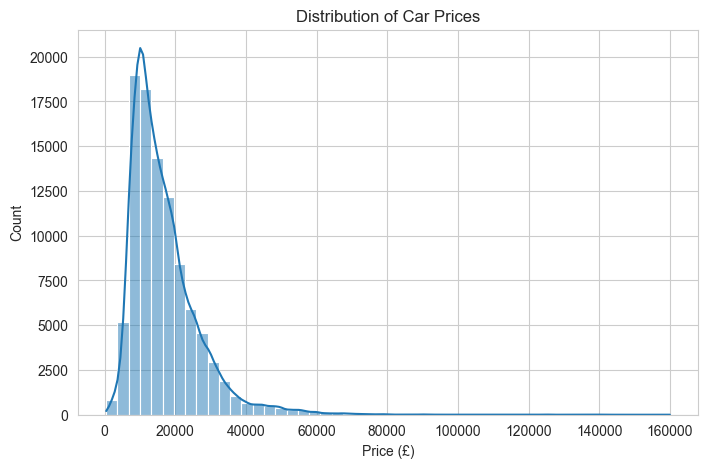

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (£)')
plt.show()

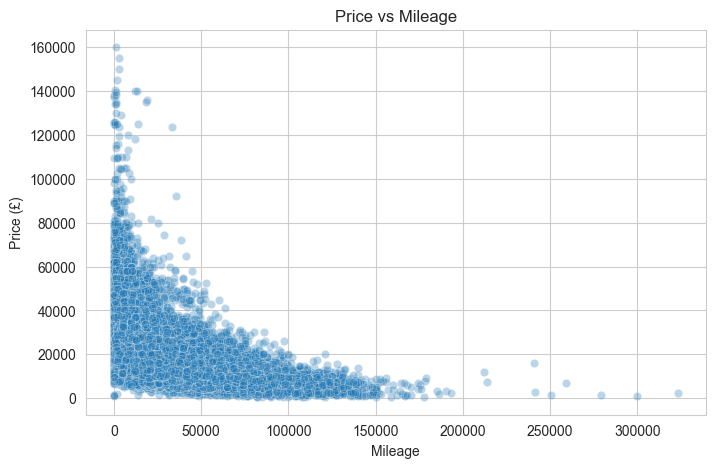

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='mileage', y='price', alpha=0.3)
plt.title('Price vs Mileage')
plt.xlabel('Mileage')
plt.ylabel('Price (£)')
plt.show()

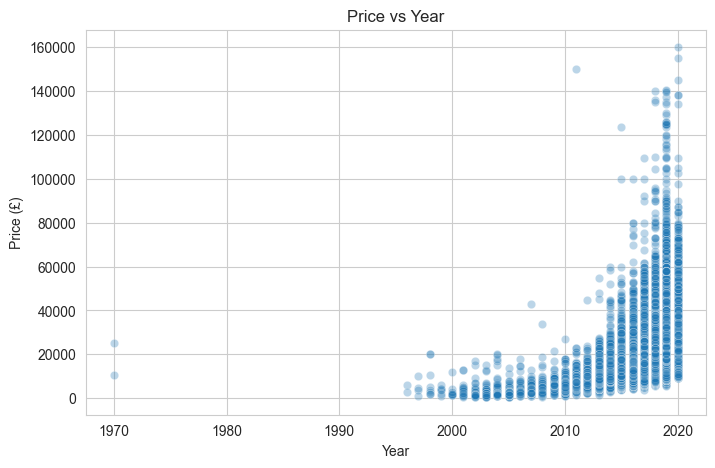

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='year', y='price', alpha=0.3)
plt.title('Price vs Year')
plt.xlabel('Year')
plt.ylabel('Price (£)')
plt.show()

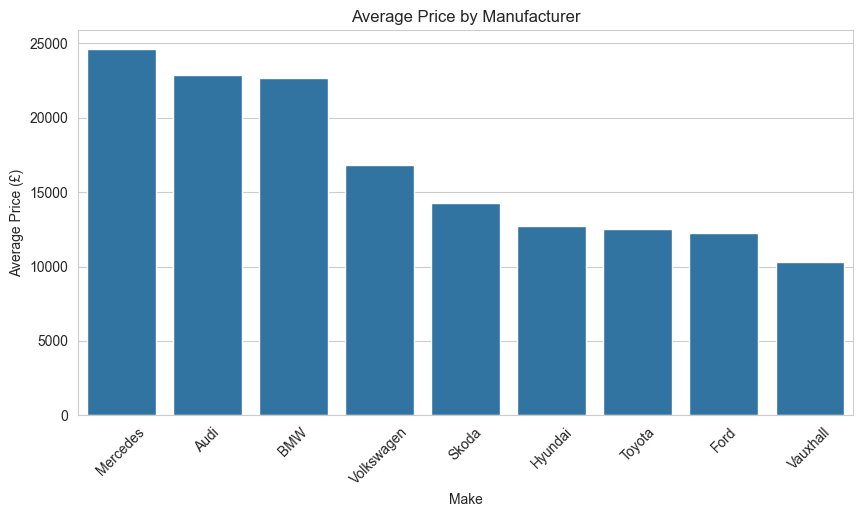

In [30]:
plt.figure(figsize=(10,5))
order = df.groupby('Make')['price'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Make', y='price', order=order, errorbar=None)
plt.title('Average Price by Manufacturer')
plt.xlabel('Make')
plt.ylabel('Average Price (£)')
plt.xticks(rotation=45)
plt.show()

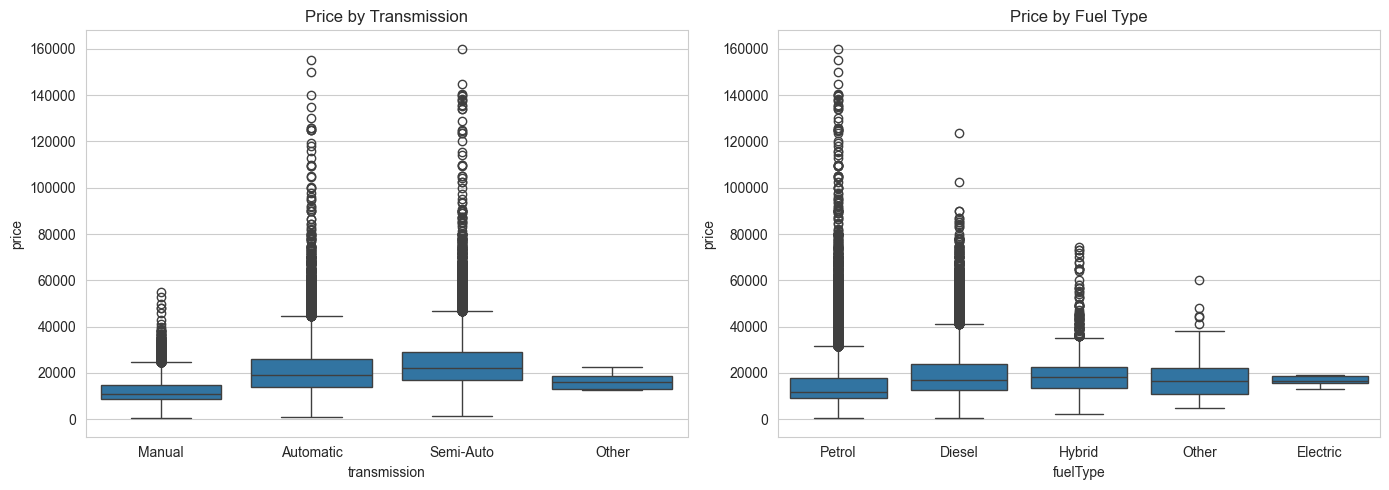

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x='transmission', y='price', ax=axes[0])
axes[0].set_title('Price by Transmission')

sns.boxplot(data=df, x='fuelType', y='price', ax=axes[1])
axes[1].set_title('Price by Fuel Type')

plt.tight_layout()
plt.show()

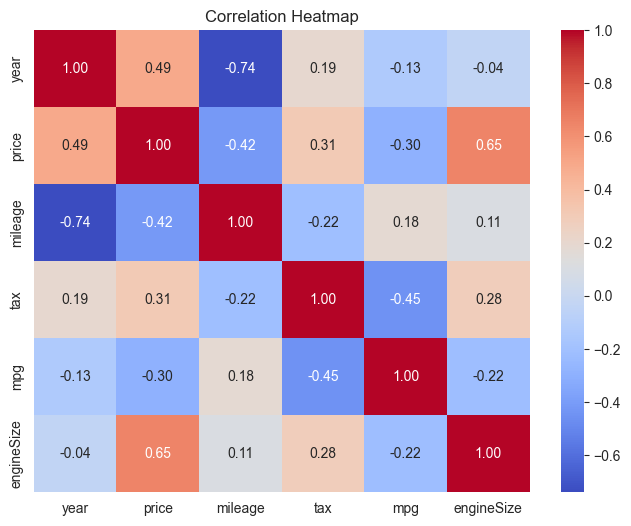

In [32]:
plt.figure(figsize=(8,6))
numeric_cols = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [33]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df.drop(columns=['price'])
y = df['price']

# First split: 70% train, 30% temp (which becomes val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: split the 30% temp evenly into 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(68397, 9) (14657, 9) (14657, 9)


In [34]:
REFERENCE_YEAR = 2020  # dataset's registrations mostly run up to ~2020, based on our EDA

for split in [X_train, X_val, X_test]:
    split['car_age'] = REFERENCE_YEAR - split['year']

In [35]:
for split in [X_train, X_val, X_test]:
    split['mileage_per_year'] = split['mileage'] / split['car_age'].replace(0, 1)

In [36]:
PREMIUM_MAKES = ['Audi', 'BMW', 'Mercedes']

for split in [X_train, X_val, X_test]:
    split['is_premium_make'] = split['Make'].isin(PREMIUM_MAKES).astype(int)

In [37]:
X_train['is_premium_make'].value_counts()

is_premium_make
0    44506
1    23891
Name: count, dtype: int64

In [38]:
numerical_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age', 'mileage_per_year']
categorical_features = ['model', 'Make', 'transmission', 'fuelType']

# is_premium_make is already 0/1 — no preprocessing needed, it passes through as-is

In [39]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit ONLY on training data — this is the critical leakage-prevention step
ohe.fit(X_train[categorical_features])

# Transform all three splits using the already-fitted encoder
X_train_cat = ohe.transform(X_train[categorical_features])
X_val_cat = ohe.transform(X_val[categorical_features])
X_test_cat = ohe.transform(X_test[categorical_features])
print(X_train_cat.shape)

(68397, 208)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Again — fit ONLY on training data
scaler.fit(X_train[numerical_features])

X_train_num = scaler.transform(X_train[numerical_features])
X_val_num = scaler.transform(X_val[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

print(X_train_num.shape)

(68397, 7)


In [41]:
import numpy as np

X_train_final = np.hstack([X_train_num, X_train_cat, X_train[['is_premium_make']].values])
X_val_final = np.hstack([X_val_num, X_val_cat, X_val[['is_premium_make']].values])
X_test_final = np.hstack([X_test_num, X_test_cat, X_test[['is_premium_make']].values])

print(X_train_final.shape, X_val_final.shape, X_test_final.shape)

(68397, 216) (14657, 216) (14657, 216)


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

lr = LinearRegression()
lr.fit(X_train_final, y_train)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_final, y_train)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train_final, y_train)

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train_final, y_train)

print("All 4 models trained.")

All 4 models trained.


In [43]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(model, X, y):
    preds = model.predict(X)
    r2 = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    return r2, mae, rmse

models = {
    'Linear Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

results = []
for name, model in models.items():
    train_r2, train_mae, train_rmse = evaluate(model, X_train_final, y_train)
    val_r2, val_mae, val_rmse = evaluate(model, X_val_final, y_val)
    results.append({
        'Model': name,
        'Train R2': train_r2, 'Val R2': val_r2,
        'Train MAE': train_mae, 'Val MAE': val_mae,
        'Train RMSE': train_rmse, 'Val RMSE': val_rmse
    })

results_df = pd.DataFrame(results)
results_df

,Model,Train R2,Val R2,Train MAE,Val MAE,Train RMSE,Val RMSE
0,Linear Regression,0.867912,0.863294,2223.846735,2232.239738,3573.072560,3653.685114
1,Decision Tree,0.999630,0.934178,18.472547,1466.185399,189.103252,2535.261394
2,Random Forest,0.993859,0.957222,441.298012,1169.270422,770.418048,2043.837309
3,Gradient Boosting,0.908420,0.904749,2024.094780,2044.072464,2975.155259,3049.807160


In [44]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [1, 5, 10]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=15,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train_final, y_train)

print("Best params:", gb_search.best_params_)

Best params: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_depth': 3, 'learning_rate': 0.2}


In [45]:
gb_tuned = gb_search.best_estimator_

train_r2, train_mae, train_rmse = evaluate(gb_tuned, X_train_final, y_train)
val_r2, val_mae, val_rmse = evaluate(gb_tuned, X_val_final, y_val)

print("BEFORE tuning — Train R2: 0.9084, Val R2: 0.9047, Val MAE: 2044.07, Val RMSE: 3049.81")
print(f"AFTER tuning  — Train R2: {train_r2:.4f}, Val R2: {val_r2:.4f}, Val MAE: {val_mae:.2f}, Val RMSE: {val_rmse:.2f}")

BEFORE tuning — Train R2: 0.9084, Val R2: 0.9047, Val MAE: 2044.07, Val RMSE: 3049.81
AFTER tuning  — Train R2: 0.9496, Val R2: 0.9445, Val MAE: 1500.57, Val RMSE: 2328.86


In [46]:
test_r2, test_mae, test_rmse = evaluate(rf, X_test_final, y_test)

print(f"FINAL TEST RESULTS — Random Forest")
print(f"R2: {test_r2:.4f}")
print(f"MAE: £{test_mae:.2f}")
print(f"RMSE: £{test_rmse:.2f}")

FINAL TEST RESULTS — Random Forest
R2: 0.9572
MAE: £1162.45
RMSE: £2074.99


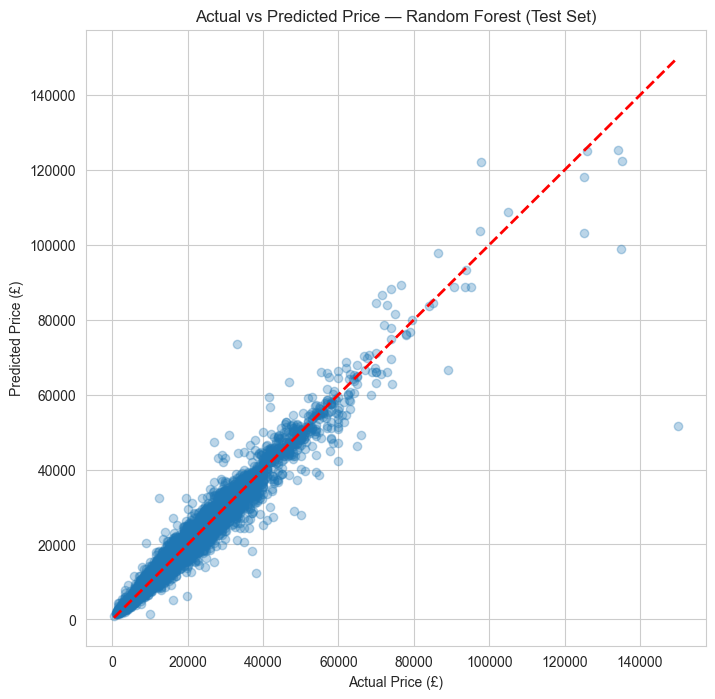

In [47]:
test_preds = rf.predict(X_test_final)

plt.figure(figsize=(8,8))
plt.scatter(y_test, test_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (£)')
plt.ylabel('Predicted Price (£)')
plt.title('Actual vs Predicted Price — Random Forest (Test Set)')
plt.show()

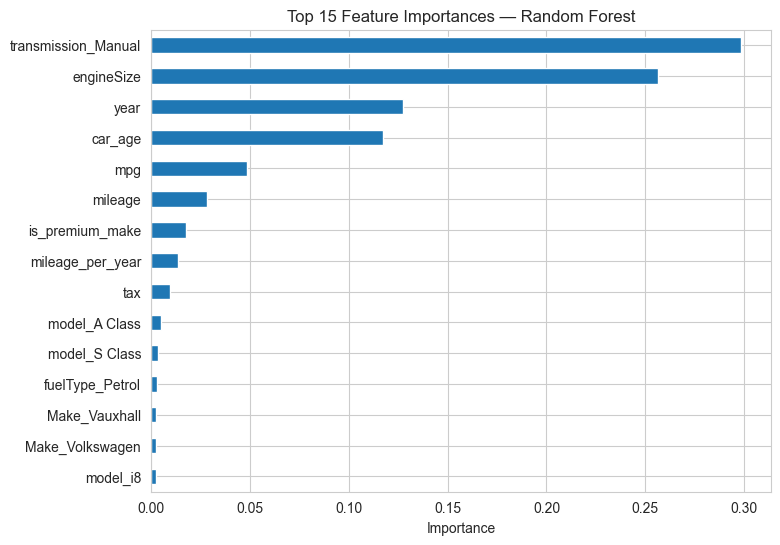

In [48]:
feature_names = (
    numerical_features
    + list(ohe.get_feature_names_out(categorical_features))
    + ['is_premium_make']
)

importances = pd.Series(rf.feature_importances_, index=feature_names)
top_15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_15.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances — Random Forest')
plt.show()

In [51]:
errors = np.abs(y_test.values - test_preds)
worst_idx = np.argsort(errors)[-15:]  # 15 largest errors

worst_cases = X_test.iloc[worst_idx].copy()
worst_cases['actual_price'] = y_test.values[worst_idx]
worst_cases['predicted_price'] = test_preds[worst_idx]
worst_cases['error'] = errors[worst_idx]

worst_cases.sort_values('error', ascending=False)

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age,mileage_per_year,is_premium_make,actual_price,predicted_price,error
44279,SL CLASS,2011,Automatic,3000,Petrol,570,21.4,6.2,Mercedes,9,333.333333,1,149948,51632.560000,98315.440000
28631,Mustang,2017,Automatic,12000,Petrol,145,20.8,5.0,Ford,3,4000.000000,0,32990,73617.110000,40627.110000
3367,R8,2019,Automatic,1000,Petrol,145,32.8,5.2,Audi,1,1000.000000,1,135000,98910.550000,36089.450000
22488,Focus,2017,Manual,197,Diesel,145,74.3,1.5,Ford,3,65.666667,0,38015,12468.250000,25546.750000
54555,A Class,2019,Automatic,163,Petrol,145,30.1,4.0,Mercedes,1,163.000000,1,97900,122062.650000,24162.650000
53549,C Class,2019,Semi-Auto,200,Petrol,145,28.0,4.0,Mercedes,1,200.000000,1,88995,66643.950000,22351.050000
33362,Mustang,2017,Manual,21575,Petrol,145,20.9,5.0,Ford,3,7191.666667,0,49999,27907.230000,22091.770000
3359,R8,2019,Automatic,100,Petrol,145,24.1,5.2,Audi,1,100.000000,1,125000,103039.040000,21960.960000
17214,2 Series,2019,Automatic,8205,Petrol,145,32.5,3.0,BMW,1,8205.000000,1,26995,47255.040000,20260.040000
701,Q7,2016,Semi-Auto,26705,Diesel,200,47.9,3.0,Audi,4,6676.250000,1,12500,32385.090000,19885.090000


In [52]:
def deal_advisor(predicted_price, seller_price):
    diff = predicted_price - seller_price
    pct_diff = (diff / predicted_price) * 100

    if pct_diff > 10:
        rating = "🟢 Great Deal"
    elif pct_diff >= 5:
        rating = "🟢 Good Deal"
    elif pct_diff >= -5:
        rating = "🟡 Fair Price"
    elif pct_diff >= -10:
        rating = "🟠 Slightly Overpriced"
    else:
        rating = "🔴 Overpriced"

    return {
        'predicted_price': round(predicted_price, 2),
        'seller_price': seller_price,
        'difference': round(diff, 2),
        'pct_difference': round(pct_diff, 2),
        'rating': rating
    }

In [53]:
# Grab a real example from the test set
example_idx = 0
predicted = rf.predict(X_test_final[example_idx].reshape(1, -1))[0]
actual_seller_price = y_test.values[example_idx]  # pretend this is what a seller is asking

result = deal_advisor(predicted, actual_seller_price)
for k, v in result.items():
    print(f"{k}: {v}")

predicted_price: 8739.93
seller_price: 8595
difference: 144.93
pct_difference: 1.66
rating: 🟡 Fair Price


In [54]:
# Test all 5 categories deliberately using made-up seller prices against one real prediction
test_predicted = 20000  # pretend the model predicted £20,000 for some car

test_cases = [
    ("Great Deal case", 17000),   # seller asks well below market (15% below)
    ("Good Deal case", 18500),    # seller asks a bit below market (7.5% below)
    ("Fair Price case", 20200),   # seller asks close to market (1% above)
    ("Slightly Overpriced case", 21500),  # seller asks a bit above market (7.5% above)
    ("Overpriced case", 23000),   # seller asks well above market (15% above)
]

for label, seller_price in test_cases:
    result = deal_advisor(test_predicted, seller_price)
    print(f"{label}: {result['rating']} (pct_diff: {result['pct_difference']}%)")

Great Deal case: 🟢 Great Deal (pct_diff: 15.0%)
Good Deal case: 🟢 Good Deal (pct_diff: 7.5%)
Fair Price case: 🟡 Fair Price (pct_diff: -1.0%)
Slightly Overpriced case: 🟠 Slightly Overpriced (pct_diff: -7.5%)
Overpriced case: 🔴 Overpriced (pct_diff: -15.0%)


In [55]:
import joblib

joblib.dump(rf, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(ohe, 'encoder.pkl')

print("Saved model, scaler, and encoder.")

Saved model, scaler, and encoder.


In [56]:
# Run this cell in your notebook, after the joblib.dump(rf/scaler/encoder) cell.
# Saves the valid dropdown options the Streamlit app needs, plus the exact
# feature ordering, so the app's preprocessing matches training exactly.

import json

metadata = {
    'makes': sorted(df['Make'].unique().tolist()),
    'models_by_make': {
        make: sorted(df[df['Make'] == make]['model'].unique().tolist())
        for make in df['Make'].unique()
    },
    'transmissions': sorted(df['transmission'].unique().tolist()),
    'fuel_types': sorted(df['fuelType'].unique().tolist()),
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'reference_year': 2020,
    'premium_makes': ['Audi', 'BMW', 'Mercedes'],
    'year_min': int(df['year'].min()),
    'year_max': int(df['year'].max()),
    'mileage_max': int(df['mileage'].max()),
    'engine_size_max': float(df['engineSize'].max()),
}

with open('app_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved app_metadata.json")

Saved app_metadata.json
